# Bayesian variable selection

The data for the variable selection in major depressive disorder was obtained from the Nathan Kline Institute - Rockland Sample. As we cannot share these data here, we use instead a simulated example.

In [1]:
%load_ext autoreload
%autoreload 2

import os

# For JAX, we can use CPU (set SELECTED_DEVICE to empty (''), or one of the available GPUs)
SELECTED_DEVICE = '0'
print(f'Setting CUDA visible devices to [{SELECTED_DEVICE}]')
os.environ['CUDA_VISIBLE_DEVICES'] = f'{SELECTED_DEVICE}'

Setting CUDA visible devices to [0]


In [2]:
import sys
sys.path.append('/scratch/big/home/maxhin/Documents/Repos/bamojax')

In [3]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)  # Do we need this here? -> it seems we do for the LML computations (otherwise NaNs get introduced), but not for performance

import jax.random as jrnd
import jax.numpy as jnp
import distrax as dx
import blackjax
import jax.scipy.special as jsp

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import sys

from blackjax import normal_random_walk

import bamojax
from bamojax.base import Model
from bamojax.sampling import gibbs_sampler, smc_inference_loop

print('Python version:       ', sys.version)
print('Jax version:          ', jax.__version__)
print('BlackJax version:     ', blackjax.__version__)
print('Distrax version:      ', dx.__version__)
print('BaMoJax version:      ', bamojax.__version__)
print('Jax default backend:  ', jax.default_backend())
print('Jax devices:          ', jax.devices())

SMALL_SIZE = 14
MEDIUM_SIZE = 16
LARGE_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=LARGE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title

Python version:        3.10.15 (main, Oct  3 2024, 07:27:34) [GCC 11.2.0]
Jax version:           0.4.35
BlackJax version:      1.2.4
Distrax version:       0.1.5
BaMoJax version:       0.0.1
Jax default backend:   gpu
Jax devices:           [CudaDevice(id=0)]


In [4]:
def read_data(key, N=100):
    key, key_X, key_y = jrnd.split(key, 3)
    beta_true = jnp.array([1.0, 0.0, 0.0, 4.3, -2.8])
    p = len(beta_true)    
    X = jrnd.normal(key_X, shape=(N, p))
    sigma_true = 0.7
    y = jnp.dot(X, beta_true) + sigma_true*jrnd.normal(key_y, shape=(N, ))
    return X, y, beta_true

#

In [15]:
def boxplot_coefficients(ax, samples, ylabel, labels=None, sortbysize=True, truth=None):    
    mean = jnp.mean(samples, axis=0)
    p = len(mean)
    if sortbysize:
        ix = jnp.argsort(jnp.abs(mean))[::-1]
    else:
        ix = jnp.arange(p)
    samples = samples[:, ix]

    if labels == None:
        labels = p*['']
    elif labels == 'infer':
        labels = [r'$x_{{{:d}}}$'.format(i) for i in jnp.arange(p)[ix]]
    else:
        labels = [labels[i] for i in ix]

    ax.axhline(y=0.0, lw=0.5, color='k', ls='--')
    bp = ax.boxplot(samples,
                    patch_artist=True, 
                    tick_labels=labels,
                    boxprops=dict(facecolor='#FDB97D',
                                  linewidth=0.5),
                    showcaps=False,
                    medianprops=dict(color='k',
                                     linestyle='-',
                                     linewidth=0.5),
                    whiskerprops=dict(solid_capstyle='butt',
                                      linewidth=0.5),
                    showfliers=False)
    
    if truth is not None:
        ax.plot(jnp.arange(p)+1, truth[ix], 'x', ms=10, color='tab:blue')

    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel('Predictors')
    ax.set_ylabel(ylabel)
    return bp

#

Regular linear regression with Gaussian priors (ridge regression):

In [7]:
key = jrnd.PRNGKey(42)
key, subkey = jrnd.split(key)

print('Loading data')
X, y, beta_true = read_data(subkey, N=100)
p = X.shape[1]

def lin_reg_link_fn(beta, sigma, x):
    mu = jnp.dot(x, beta)
    return dict(loc=mu, scale=sigma)

#


LinearRegression = Model('BLR')
sigma = LinearRegression.add_node('sigma', distribution=dx.Transformed(dx.Normal(loc=0., scale=1.), tfb.Exp()))
beta = LinearRegression.add_node('beta', distribution=dx.Normal(loc=0., scale=1.), shape=(p, ))
x_node = LinearRegression.add_node('x', observations=X)
y_node = LinearRegression.add_node('y', observations=y, distribution=dx.Normal, parents=dict(beta=beta, sigma=sigma, x=x_node), link_fn=lin_reg_link_fn)

print('Gibbs conditionals: ')
LinearRegression.print_gibbs()

Loading data
Gibbs conditionals: 
Gibbs structure:
beta                : p(y | beta, x, sigma) p(beta)
sigma               : p(y | beta, x, sigma) p(sigma)


Set up Gibbs-in-SMC

In [13]:
%%time

num_mcmc_steps = 100
num_particles = 1_000

step_fns = dict(beta=normal_random_walk, sigma=normal_random_walk)
step_fn_params = dict(beta=dict(sigma=0.05*jnp.eye(p)), sigma=dict(sigma=0.3))

gibbs = gibbs_sampler(LinearRegression, step_fns=step_fns, step_fn_params=step_fn_params)

key, subkey = jrnd.split(key)
final_state, lml, n_iter, final_info = smc_inference_loop(subkey, model=LinearRegression, kernel=gibbs, num_particles=num_particles, num_mcmc_steps=num_mcmc_steps)

for theta in ['beta', 'sigma']:
    print(f'Acceptance rate for {theta}: {jnp.mean(final_info.update_info[theta].is_accepted):0.3f}')

Acceptance rate for beta: 0.512
Acceptance rate for sigma: 0.231
CPU times: user 13.3 s, sys: 620 ms, total: 13.9 s
Wall time: 7.97 s


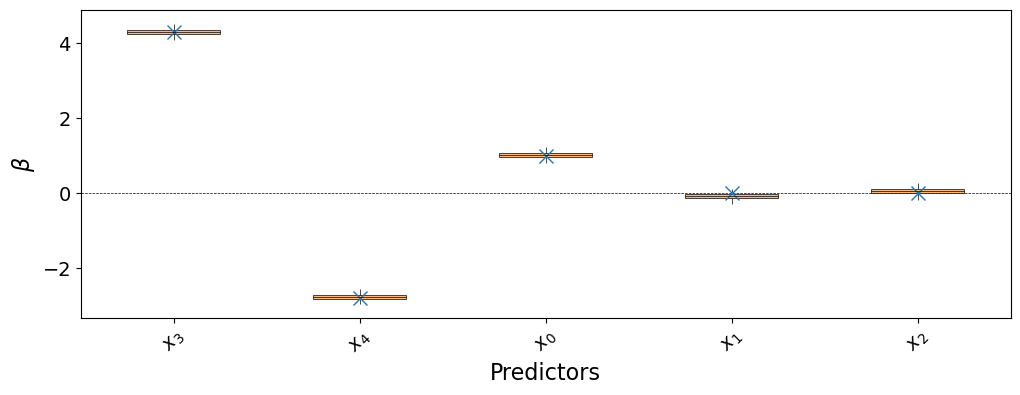

In [16]:
plt.figure(figsize=(12, 4))
_ = boxplot_coefficients(plt.gca(), final_state.particles['beta'], r'$\beta$', sortbysize=True, labels='infer', truth=beta_true)


Variable selection with the LN-CASS prior (regularizing coefficients towards zero; see Thomson et al., 2019):

In [17]:
mu_v = jsp.logit(0.2)
sigma_v = 1.0 

def lin_reg_link_fn(beta, sigma, x):
    mu = jnp.dot(x, beta)
    return dict(loc=mu, scale=sigma)

#

LNCASS = Model('SBLR')
sigma = LNCASS.add_node('sigma', distribution=dx.Transformed(dx.Normal(loc=0., scale=1.), tfb.Exp()))
tau = LNCASS.add_node('tau', distribution=dx.Transformed(dx.Normal(loc=0., scale=1.), tfb.Exp()))
lam = LNCASS.add_node('lam', dx.Transformed(dx.Normal(loc=mu_v*jnp.ones((p, )), scale=sigma_v*jnp.ones((p, ))), tfb.Sigmoid()))
beta = LNCASS.add_node('beta', distribution=dx.Normal, parents=dict(tau=tau, lam=lam), link_fn=lambda tau, lam: dict(loc=0.0, scale=(tau*lam)**2))
x_node = LNCASS.add_node('x', observations=X)
y_node = LNCASS.add_node('y', observations=y, distribution=dx.Normal, parents=dict(beta=beta, sigma=sigma, x=x_node), link_fn=lin_reg_link_fn)

LNCASS.print_gibbs()

Gibbs structure:
tau                 : p(beta | tau, lam) p(tau)
lam                 : p(beta | tau, lam) p(lam)
beta                : p(y | beta, x, sigma) p(beta | tau, lam)
sigma               : p(y | beta, x, sigma) p(sigma)


In [18]:
%%time

num_mcmc_steps = 100
num_particles = 1_000

step_fns = dict(beta=normal_random_walk, 
                sigma=normal_random_walk, 
                lam=normal_random_walk, 
                tau=normal_random_walk)
step_fn_params = dict(beta=dict(sigma=0.05*jnp.eye(p)), 
                      lam=dict(sigma=0.01*jnp.eye(p)), 
                      sigma=dict(sigma=0.5), 
                      tau=dict(sigma=0.5))

gibbs = gibbs_sampler(LNCASS, step_fns=step_fns, step_fn_params=step_fn_params)

key, subkey = jrnd.split(key)
final_state, lml, n_iter, final_info = smc_inference_loop(subkey, model=LNCASS, kernel=gibbs, num_particles=num_particles, num_mcmc_steps=num_mcmc_steps)

for theta in ['beta', 'sigma', 'lam', 'tau']:
    print(f'Acceptance rate for {theta}: {jnp.mean(final_info.update_info[theta].is_accepted):0.3f}')

Acceptance rate for beta: 0.406
Acceptance rate for sigma: 0.133
Acceptance rate for lam: 0.831
Acceptance rate for tau: 0.751
CPU times: user 20.7 s, sys: 769 ms, total: 21.5 s
Wall time: 13.3 s


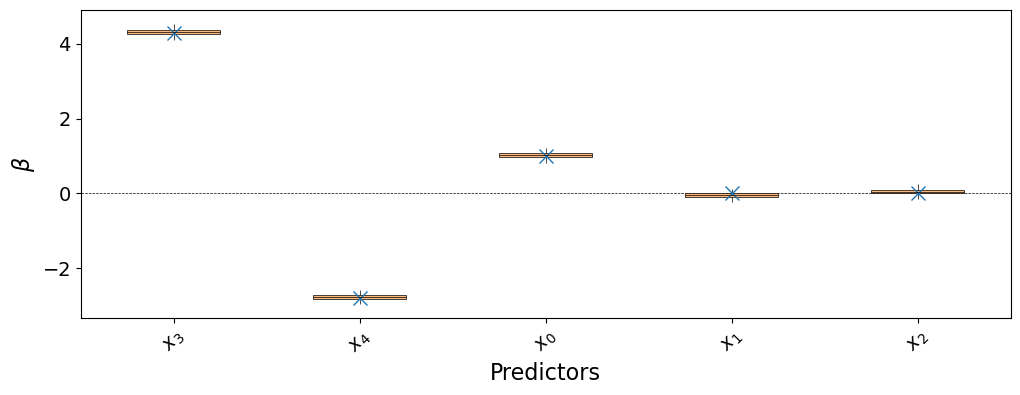

In [19]:
plt.figure(figsize=(12, 4))
_ = boxplot_coefficients(plt.gca(), final_state.particles['beta'], r'$\beta$', sortbysize=True, labels='infer', truth=beta_true)